In [48]:
import pandas as pd

In [49]:
ondemand_only_df        = pd.read_csv('data/70B/offline/offline_ondemand_only_20min.csv')
shuntserve_df           = pd.read_csv('data/70B/offline/offline_shuntserve_20min.csv')
stage_switching_df      = pd.read_csv('data/70B/offline/offline_stage_switching_20min.csv')
request_migration_df    = pd.read_csv('data/70B/offline/offline_request_migration_20min.csv')
no_handle_df            = pd.read_csv('data/70B/offline/offline_no_handle_20min.csv')

In [50]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_rps_with_moving_average(df, window=5, max_time=None):
    """
    Calculate requests per second (RPS) with moving average.

    Parameters:
    - df: DataFrame with 'ArrivalTime' and 'CompletionTime' columns
    - window: Window size in seconds (절반씩 앞뒤로 적용)
    - max_time: Maximum time to calculate RPS for (in seconds). If None, use all data.

    Returns:
    - times: Array of time points (in seconds from start)
    - rps: Array of RPS values
    """
    # Normalize time: use first arrival time as baseline (t=0)
    base_time = df['ArrivalTime'].min()
    completion_times = df['CompletionTime'].values - base_time

    # Determine time range
    if max_time is None:
        max_time_calc = int(np.ceil(completion_times.max()))
    else:
        max_time_calc = max_time

    # Count requests completed in each second
    time_points = np.arange(0, max_time_calc + 1)
    rps_values = []

    window_half_size = window // 2

    for t in time_points:
        if window_half_size == 0:
            # Count only requests completed in this exact second [t, t+1)
            count = np.sum((completion_times >= t) & (completion_times < t + 1))
        else:
            # Count requests in the window [t-window_half_size, t+window_half_size+1)
            # 앞뒤로 window_half_size초씩
            window_start = max(0, t - window_half_size)
            window_end = t + window_half_size + 1
            count = np.sum((completion_times >= window_start) & (completion_times < window_end))
            # Average over the actual window size
            # actual_window_size = window_end - window_start
            count = count / window

        rps_values.append(count)

    return time_points, np.array(rps_values)

In [51]:
def plot_rps_comparison(times_dict, rps_dict, window_size, 
                        include_ondemand=False,
                        stride=1,
                        show_average_line=False,
                        title=None,
                        figsize=(14, 6),
                        font_size_xlabel=16,
                        font_size_ylabel=16,
                        font_size_title=18,
                        font_size_legend=14,
                        font_size_ticks=12,
                        linewidth=2,
                        alpha=0.8):
    """
    Plot RPS comparison over time for different approaches.
    
    Parameters:
    - times_dict: Dictionary with approach names as keys and time arrays as values
    - rps_dict: Dictionary with approach names as keys and RPS arrays as values
    - window_size: Moving average window size used in calculation
    - include_ondemand: Whether to include 'ondemand' in the plot
    - stride: Plot every N-th data point (default=1, plot all points). Higher values reduce plot density.
    - show_average_line: If True, show horizontal line at average RPS for each approach
    - title: Custom title (if None, uses default)
    - figsize: Figure size (width, height)
    - font_size_*: Font sizes for different elements
    - linewidth: Line width for plots
    - alpha: Transparency for lines
    """
    plt.figure(figsize=figsize)
    
    # Define which approaches to plot
    approach_order = ['shuntserve', 'concurrent_initialization', 'request_migration', 'no_handle']
    if include_ondemand:
        approach_order = ['ondemand'] + approach_order
    
    # Define line styles for each approach
    # line_styles = {
    #     'ondemand': '-',           # solid
    #     'shuntserve': '--',        # dashed
    #     'stage_switching': '-.',   # dash-dot
    #     'request_migration': ':',  # dotted
    #     'no_handle': (0, (3, 1, 1, 1))  # dash-dot-dot
    # }

    line_styles = {
        'ondemand': '-',          
        'shuntserve': '-',        
        'concurrent_initialization': '-',   
        'request_migration': '-', 
        'no_handle': '-'  
    }
    
    # Track max RPS value for y-axis scaling
    max_rps = 0
    min_rps = float('inf')
    
    # Plot each approach
    for approach in approach_order:
        if approach in times_dict and approach in rps_dict:
            label_map = {
                'ondemand': 'On-demand Only',
                'shuntserve': 'Shuntserve',
                'concurrent_initialization': 'Concurrent Initialization',
                'request_migration': 'Request Migration',
                'no_handle': 'No Handle'
            }
            label = label_map.get(approach, approach)
            
            # Apply stride: select every stride-th element
            times_strided = times_dict[approach][::stride]
            rps_strided = rps_dict[approach][::stride]
            
            # Update max RPS
            max_rps = max(max_rps, np.max(rps_dict[approach]))
            min_rps = min(min_rps, np.min(rps_dict[approach]))
            
            # Get line style for this approach
            linestyle = line_styles.get(approach, '-')
            
            # Plot the time series
            line = plt.plot(times_strided, rps_strided, 
                    label=label, linewidth=linewidth, alpha=alpha, linestyle=linestyle)
            
            # Add horizontal average line if requested
            if show_average_line:
                avg_rps = np.mean(rps_dict[approach])
                color = line[0].get_color()
                plt.axhline(y=avg_rps, color=color, linestyle='--', 
                           linewidth=1.5, alpha=0.6)
    
    # Add a legend entry for average line if shown
    if show_average_line:
        # Create a dummy line for the legend
        plt.plot([], [], color='gray', linestyle='--', linewidth=1.5, alpha=0.6, label='Avg RPS')
    
    # Add labels and title
    plt.xlabel('Time (seconds)', fontsize=font_size_xlabel)
    plt.ylabel('Requests Per Second (RPS)', fontsize=font_size_ylabel)
    
    # if title is None:
    #     title = f'LLM Serving Throughput Comparison: Spot Interruption Handling Strategies\n(Moving Average Window: {window_size}s)'
    plt.title(title, fontsize=font_size_title, fontweight='bold')
    
    # Set y-axis range to 1.3x max value
    plt.ylim(min_rps, max_rps * 1.3)
    
    # Set tick font sizes
    plt.xticks(fontsize=font_size_ticks)
    plt.yticks(fontsize=font_size_ticks)
    
    # Add legend
    plt.legend(loc='best', fontsize=font_size_legend, framealpha=0.9)
    
    # Adjust layout
    plt.tight_layout()
    
    # Display the plot
    plt.show()

Window size: 30 seconds
Duration: None seconds
On-demand Only - Duration: 3544 seconds, Peak RPS: 6.07
Shuntserve - Duration: 4141 seconds, Peak RPS: 5.63
Stage Switching - Duration: 4339 seconds, Peak RPS: 6.57
Request Migration - Duration: 4404 seconds, Peak RPS: 6.10
No Handle - Duration: 4691 seconds, Peak RPS: 5.03


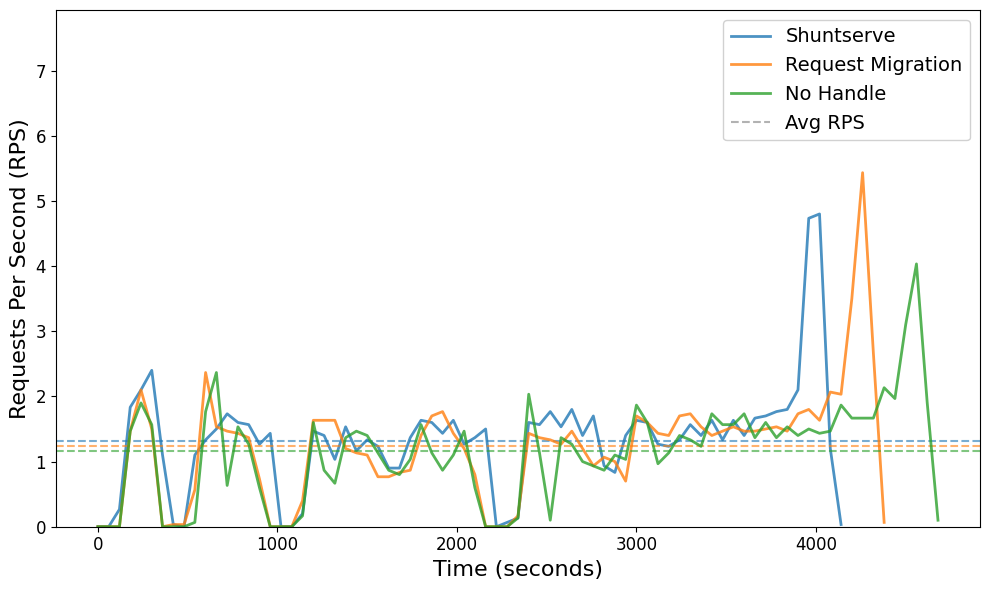

In [52]:
# Set window size for moving average (0 = no averaging, just count per second)
window_size = 30
duration = None  

# Calculate RPS for each approach 
ondemand_times, ondemand_rps = calculate_rps_with_moving_average(ondemand_only_df, window=window_size, max_time=duration)
shuntserve_times, shuntserve_rps = calculate_rps_with_moving_average(shuntserve_df, window=window_size, max_time=duration)
stage_switching_times, stage_switching_rps = calculate_rps_with_moving_average(stage_switching_df, window=window_size, max_time=duration)
request_migration_times, request_migration_rps = calculate_rps_with_moving_average(request_migration_df, window=window_size, max_time=duration)
no_handle_times, no_handle_rps = calculate_rps_with_moving_average(no_handle_df, window=window_size, max_time=duration)


print(f"Window size: {window_size} seconds")
print(f"Duration: {duration} seconds")
print(f"On-demand Only - Duration: {ondemand_times[-1]} seconds, Peak RPS: {ondemand_rps.max():.2f}")
print(f"Shuntserve - Duration: {shuntserve_times[-1]} seconds, Peak RPS: {shuntserve_rps.max():.2f}")
print(f"Stage Switching - Duration: {stage_switching_times[-1]} seconds, Peak RPS: {stage_switching_rps.max():.2f}")
print(f"Request Migration - Duration: {request_migration_times[-1]} seconds, Peak RPS: {request_migration_rps.max():.2f}")
print(f"No Handle - Duration: {no_handle_times[-1]} seconds, Peak RPS: {no_handle_rps.max():.2f}")


# Create RPS comparison plot using the function
times_dict = {
    'ondemand': ondemand_times,
    'shuntserve': shuntserve_times,
    'stage_switching': stage_switching_times,
    'request_migration': request_migration_times,
    'no_handle': no_handle_times
}

rps_dict = {
    'ondemand': ondemand_rps,
    'shuntserve': shuntserve_rps,
    'stage_switching': stage_switching_rps,
    'request_migration': request_migration_rps,
    'no_handle': no_handle_rps
}

plot_rps_comparison(
    title=None,
    times_dict=times_dict,
    rps_dict=rps_dict,
    window_size=window_size,
    include_ondemand=False,
    show_average_line=True,
    stride=60,
    font_size_xlabel=16,  # Original had fontsize=1 for xlabel
    font_size_ylabel=16,
    font_size_title=18,
    font_size_legend=14,
    font_size_ticks=12,
    figsize=(10, 6),
)

In [53]:
# Set window size for moving average (0 = no averaging, just count per second)
window_size = 600
duration = 3000  

# Calculate RPS for each approach 
ondemand_times, ondemand_rps = calculate_rps_with_moving_average(ondemand_only_df, window=window_size, max_time=duration)
shuntserve_times, shuntserve_rps = calculate_rps_with_moving_average(shuntserve_df, window=window_size, max_time=duration)
stage_switching_times, stage_switching_rps = calculate_rps_with_moving_average(stage_switching_df, window=window_size, max_time=duration)
request_migration_times, request_migration_rps = calculate_rps_with_moving_average(request_migration_df, window=window_size, max_time=duration)
no_handle_times, no_handle_rps = calculate_rps_with_moving_average(no_handle_df, window=window_size, max_time=duration)


print(f"Window size: {window_size} seconds")
print(f"Duration: {duration} seconds")
print(f"On-demand Only - Duration: {ondemand_times[-1]} seconds, Peak RPS: {ondemand_rps.max():.2f}")
print(f"Shuntserve - Duration: {shuntserve_times[-1]} seconds, Peak RPS: {shuntserve_rps.max():.2f}")
print(f"Stage Switching - Duration: {stage_switching_times[-1]} seconds, Peak RPS: {stage_switching_rps.max():.2f}")
print(f"Request Migration - Duration: {request_migration_times[-1]} seconds, Peak RPS: {request_migration_rps.max():.2f}")
print(f"No Handle - Duration: {no_handle_times[-1]} seconds, Peak RPS: {no_handle_rps.max():.2f}")

Window size: 600 seconds
Duration: 3000 seconds
On-demand Only - Duration: 3000 seconds, Peak RPS: 1.63
Shuntserve - Duration: 3000 seconds, Peak RPS: 1.35
Stage Switching - Duration: 3000 seconds, Peak RPS: 1.34
Request Migration - Duration: 3000 seconds, Peak RPS: 1.28
No Handle - Duration: 3000 seconds, Peak RPS: 1.18


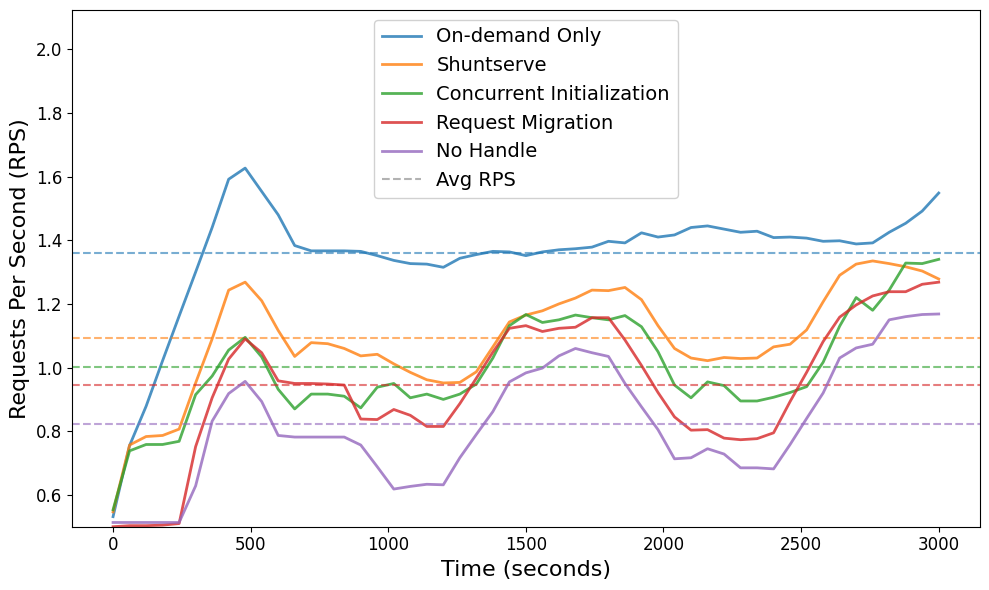

In [73]:
# Create RPS comparison plot using the function
times_dict = {
    'ondemand': ondemand_times,
    'shuntserve': shuntserve_times,
    'concurrent_initialization': stage_switching_times,
    'request_migration': request_migration_times,
    'no_handle': no_handle_times
}

rps_dict = {
    'ondemand': ondemand_rps,
    'shuntserve': shuntserve_rps,
    'concurrent_initialization': stage_switching_rps,
    'request_migration': request_migration_rps,
    'no_handle': no_handle_rps
}

plot_rps_comparison(
    title=None,
    times_dict=times_dict,
    rps_dict=rps_dict,
    window_size=window_size,
    show_average_line=True,
    include_ondemand=True,
    stride=60,
    font_size_xlabel=16,  # Original had fontsize=1 for xlabel
    font_size_ylabel=16,
    font_size_title=18,
    font_size_legend=14,
    font_size_ticks=12,
    figsize=(10, 6),
)

In [55]:
# Calculate end-to-end total throughput for each approach
def calculate_total_throughput(df, max_time=None):
    """
    Calculate end-to-end total throughput (requests per second).
    
    Parameters:
    - df: DataFrame with 'ArrivalTime' and 'CompletionTime' columns
    - max_time: Maximum time in seconds from start. If None, use all data.
    
    Returns:
    - throughput: Total requests per second across entire duration
    """
    base_time = df['ArrivalTime'].min()
    
    if max_time is None:
        # Use all data
        total_duration = df['CompletionTime'].max() - base_time
        total_requests = len(df)
    else:
        # Only count requests completed within max_time
        cutoff_time = base_time + max_time
        completed_within_time = df[df['CompletionTime'] <= cutoff_time]
        total_duration = max_time
        total_requests = len(completed_within_time)
    
    throughput = total_requests / total_duration
    return throughput, total_duration, total_requests

In [56]:
# Calculate throughput for each approach (only within 30 minutes)
ondemand_throughput, ondemand_duration, ondemand_requests = calculate_total_throughput(ondemand_only_df, max_time=duration)
shuntserve_throughput, shuntserve_duration, shuntserve_requests = calculate_total_throughput(shuntserve_df, max_time=duration)
stage_switching_throughput, stage_switching_duration, stage_switching_requests = calculate_total_throughput(stage_switching_df, max_time=duration)
request_migration_throughput, request_migration_duration, request_migration_requests = calculate_total_throughput(request_migration_df, max_time=duration)
no_handle_throughput, no_handle_duration, no_handle_requests = calculate_total_throughput(no_handle_df, max_time=duration)

print(f"End-to-End Total Throughput")
print(f"On-demand Only: {ondemand_throughput:.2f} RPS ({ondemand_requests} requests / {ondemand_duration:.2f}s)")
print(f"ShuntServe : {shuntserve_throughput:.2f} RPS ({shuntserve_requests} requests / {shuntserve_duration:.2f}s)")
print(f"Stage Switching: {stage_switching_throughput:.2f} RPS ({stage_switching_requests} requests / {stage_switching_duration:.2f}s)")
print(f"Request Migration: {request_migration_throughput:.2f} RPS ({request_migration_requests} requests / {request_migration_duration:.2f}s)")
print(f"No Handle: {no_handle_throughput:.2f} RPS ({no_handle_requests} requests / {no_handle_duration:.2f}s)")

End-to-End Total Throughput
On-demand Only: 1.37 RPS (4097 requests / 3000.00s)
ShuntServe : 1.10 RPS (3300 requests / 3000.00s)
Stage Switching: 1.01 RPS (3039 requests / 3000.00s)
Request Migration: 0.94 RPS (2825 requests / 3000.00s)
No Handle: 0.83 RPS (2482 requests / 3000.00s)


In [57]:
g6_12xlarge_ondemand_price_per_hour = 4.6016
g5_12xlarge_ondemand_price_per_hour = 5.6720
g6e_xlarge_ondemand_price_per_hour = 1.8610

g6_12xlarge_spot_price_per_hour = 1.9445
g5_12xlarge_spot_price_per_hour = 2.2915
g6e_xlarge_spot_price_per_hour = 0.7040


ondemand_only_ondemand_time_g6_12xlarge_min = 150
ondemand_only_ondemand_time_g5_12xlarge_min = 100
ondemand_only_ondemand_time_g6e_xlarge_min = 200
ondemand_only_spot_time_g6_12xlarge_min = 0
ondemand_only_spot_time_g5_12xlarge_min = 0
ondemand_only_spot_time_g6e_xlarge_min = 0



g6_12xlarge_ondemand_time_with_mixed = 25
g5_12xlarge_ondemand_time_with_mixed = 60
g6e_xlarge_ondemand_time_with_mixed = 80
g6_12xlarge_spot_time_with_mixed = 125
g5_12xlarge_spot_time_with_mixed = 40
g6e_xlarge_spot_time_with_mixed = 120


shuntserve_ondemand_time_g6_12xlarge_min = g6_12xlarge_ondemand_time_with_mixed
shuntserve_ondemand_time_g5_12xlarge_min = g5_12xlarge_ondemand_time_with_mixed
shuntserve_ondemand_time_g6e_xlarge_min = g6e_xlarge_ondemand_time_with_mixed
shuntserve_spot_time_g6_12xlarge_min = g6_12xlarge_spot_time_with_mixed
shuntserve_spot_time_g5_12xlarge_min = g5_12xlarge_spot_time_with_mixed
shuntserve_spot_time_g6e_xlarge_min = g6e_xlarge_spot_time_with_mixed

stage_switching_ondemand_time_g6_12xlarge_min = g6_12xlarge_ondemand_time_with_mixed
stage_switching_ondemand_time_g5_12xlarge_min = g5_12xlarge_ondemand_time_with_mixed
stage_switching_ondemand_time_g6e_xlarge_min = g6e_xlarge_ondemand_time_with_mixed
stage_switching_spot_time_g6_12xlarge_min = g6_12xlarge_spot_time_with_mixed
stage_switching_spot_time_g5_12xlarge_min = g5_12xlarge_spot_time_with_mixed
stage_switching_spot_time_g6e_xlarge_min = g6e_xlarge_spot_time_with_mixed

request_migration_ondemand_time_g6_12xlarge_min = g6_12xlarge_ondemand_time_with_mixed
request_migration_ondemand_time_g5_12xlarge_min = g5_12xlarge_ondemand_time_with_mixed
request_migration_ondemand_time_g6e_xlarge_min = g6e_xlarge_ondemand_time_with_mixed
request_migration_spot_time_g6_12xlarge_min = g6_12xlarge_spot_time_with_mixed
request_migration_spot_time_g5_12xlarge_min = g5_12xlarge_spot_time_with_mixed
request_migration_spot_time_g6e_xlarge_min = g6e_xlarge_spot_time_with_mixed

no_handle_ondemand_time_g6_12xlarge_min = g6_12xlarge_ondemand_time_with_mixed
no_handle_ondemand_time_g5_12xlarge_min = g5_12xlarge_ondemand_time_with_mixed
no_handle_ondemand_time_g6e_xlarge_min = g6e_xlarge_ondemand_time_with_mixed
no_handle_spot_time_g6_12xlarge_min = g6_12xlarge_spot_time_with_mixed
no_handle_spot_time_g5_12xlarge_min = g5_12xlarge_spot_time_with_mixed
no_handle_spot_time_g6e_xlarge_min = g6e_xlarge_spot_time_with_mixed

In [58]:
ondemand_only_price = (
    ondemand_only_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    ondemand_only_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    ondemand_only_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    ondemand_only_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    ondemand_only_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    ondemand_only_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

shuntserve_price = (
    shuntserve_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    shuntserve_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    shuntserve_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    shuntserve_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    shuntserve_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    shuntserve_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

stage_switching_price = (
    stage_switching_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    stage_switching_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    stage_switching_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    stage_switching_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    stage_switching_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    stage_switching_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

request_migration_price = (
    request_migration_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    request_migration_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    request_migration_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    request_migration_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    request_migration_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    request_migration_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

no_handle_price = (
    no_handle_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    no_handle_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    no_handle_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    no_handle_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    no_handle_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    no_handle_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

print(f"Ondemand Only Total Price: ${ondemand_only_price:.2f}")
print(f"ShuntServe Total Price: ${shuntserve_price:.2f}")
print(f"Stage Switching Total Price: ${stage_switching_price:.2f}")
print(f"Request Migration Total Price: ${request_migration_price:.2f}")
print(f"No Handle Total Price: ${no_handle_price:.2f}")

Ondemand Only Total Price: $27.16
ShuntServe Total Price: $17.06
Stage Switching Total Price: $17.06
Request Migration Total Price: $17.06
No Handle Total Price: $17.06


In [59]:
# ShuntServe 와 Stage Switching 의 경우, Overlapped 되는 시간을 추가적으로 가격에 더해주어야 함
shuntserve_spot_g6_12xlarge_overlapped_seconds = 60.45
shuntserve_spot_g5_12xlarge_overlapped_seconds = 182.28
shuntserve_spot_g6e_xlarge_overlapped_seconds = 371.98
shuntserve_ondemand_g6_12xlarge_overlapped_seconds = 175.86
shuntserve_ondemand_g5_12xlarge_overlapped_seconds = 169.46
shuntserve_ondemand_g6e_xlarge_overlapped_seconds = 366.6

stage_switching_spot_g6_12xlarge_overlapped_seconds = 55.14
stage_switching_spot_g5_12xlarge_overlapped_seconds = 171.08
stage_switching_spot_g6e_xlarge_overlapped_seconds = 351.16
stage_switching_ondemand_g6_12xlarge_overlapped_seconds = 165.18
stage_switching_ondemand_g5_12xlarge_overlapped_seconds = 160.55
stage_switching_ondemand_g6e_xlarge_overlapped_seconds = 365.94

shuntserve_overhead_price = (
    shuntserve_spot_g6_12xlarge_overlapped_seconds * g6_12xlarge_spot_price_per_hour + 
    shuntserve_spot_g5_12xlarge_overlapped_seconds * g5_12xlarge_spot_price_per_hour + 
    shuntserve_spot_g6e_xlarge_overlapped_seconds * g6e_xlarge_spot_price_per_hour + 
    shuntserve_ondemand_g6_12xlarge_overlapped_seconds * g6_12xlarge_ondemand_price_per_hour + 
    shuntserve_ondemand_g5_12xlarge_overlapped_seconds * g5_12xlarge_ondemand_price_per_hour + 
    shuntserve_ondemand_g6e_xlarge_overlapped_seconds * g6e_xlarge_ondemand_price_per_hour
) / 3600

stage_switching_overhead_price = (
    stage_switching_spot_g6_12xlarge_overlapped_seconds * g6_12xlarge_spot_price_per_hour + 
    stage_switching_spot_g5_12xlarge_overlapped_seconds * g5_12xlarge_spot_price_per_hour + 
    stage_switching_spot_g6e_xlarge_overlapped_seconds * g6e_xlarge_spot_price_per_hour + 
    stage_switching_ondemand_g6_12xlarge_overlapped_seconds * g6_12xlarge_ondemand_price_per_hour + 
    stage_switching_ondemand_g5_12xlarge_overlapped_seconds * g5_12xlarge_ondemand_price_per_hour + 
    stage_switching_ondemand_g6e_xlarge_overlapped_seconds * g6e_xlarge_ondemand_price_per_hour
) / 3600

print(f"ShuntServe Overhead Price: ${shuntserve_overhead_price:.2f}")
print(f"Stage Switching Overhead Price: ${stage_switching_overhead_price:.2f}")
shuntserve_total_price = shuntserve_price + shuntserve_overhead_price
stage_switching_total_price = stage_switching_price + stage_switching_overhead_price
print(f"Ondemand Only Total Price: ${ondemand_only_price:.2f}")
print(f"ShuntServe Total Price: ${shuntserve_total_price:.2f}")
print(f"Stage Switching Total Price: ${stage_switching_total_price:.2f}")
print(f"Request Migration Total Price: ${request_migration_price:.2f}")
print(f"No Handle Total Price: ${no_handle_price:.2f}")

ShuntServe Overhead Price: $0.90
Stage Switching Overhead Price: $0.86
Ondemand Only Total Price: $27.16
ShuntServe Total Price: $17.96
Stage Switching Total Price: $17.92
Request Migration Total Price: $17.06
No Handle Total Price: $17.06


In [60]:
ondemand_only_throughput_per_cost = ondemand_throughput / ondemand_only_price
shuntserve_throughput_per_cost = shuntserve_throughput / shuntserve_total_price
stage_switching_throughput_per_cost = stage_switching_throughput / stage_switching_total_price
request_migration_throughput_per_cost = request_migration_throughput / request_migration_price
no_handle_throughput_per_cost = no_handle_throughput / no_handle_price

ondemand_only_throughput_per_cost, shuntserve_throughput_per_cost, stage_switching_throughput_per_cost, request_migration_throughput_per_cost, no_handle_throughput_per_cost

(0.050281043666085753,
 0.06124691228198251,
 0.056535360542345994,
 0.05520583716232226,
 0.048502969145799595)

In [71]:
def plot_throughput_cost_analysis(throughputs, costs, throughput_per_costs, 
                                   approaches=['On-demand\nOnly', 'Stage\nSwitching', 'Stop and\nStart'],
                                   title_suffix='Online',
                                   font_size_title=15,
                                   font_size_subtitle=13,
                                   font_size_label=12,
                                   font_size_value=10,
                                   font_size_legend=9,
                                   figsize=(16, 7)):
    """
    Plot throughput and cost analysis with two subplots.
    
    Parameters:
    - throughputs: List of throughput values for each approach
    - costs: List of cost values for each approach
    - throughput_per_costs: List of throughput per cost values
    - approaches: List of approach names
    - title_suffix: Suffix for the main title (e.g., 'Online' or 'Offline')
    - font_size_*: Font sizes for different elements
    - figsize: Figure size (width, height)
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#4682b4', '#ff8c42']
    patterns = ['xx', '//', '\\\\', '||', '..']  # cross, 우상향 diagonal, 좌상향 diagonal, 세로선, 점
    
    # Left subplot: Throughput bar + Cost overlay
    ax1 = axes[0]
    bars = ax1.bar(approaches, throughputs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5, label='Throughput')
    
    # Add patterns to bars
    for bar, pattern in zip(bars, patterns):
        bar.set_hatch(pattern)
    
    # Add throughput value labels on bars
    for bar, throughput in zip(bars, throughputs):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{throughput:.2f}',
                 ha='center', va='bottom', fontsize=font_size_value, fontweight='bold')
    
    ax1.set_ylabel('Throughput (RPS)', fontsize=font_size_label, fontweight='bold')
    ax1.set_ylim(0, max(throughputs) * 1.5)
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Add cost overlay with secondary y-axis
    ax1_twin = ax1.twinx()
    
    # Plot markers at actual cost values - use same marker for all
    min_cost = min(costs)
    max_cost = max(costs)
    cost_range = max_cost - min_cost
    
    for i, (approach, cost, color) in enumerate(zip(approaches, costs, colors)):
        ax1_twin.plot(i, cost, marker='o', markersize=12, color=color, linestyle='',
                      markeredgecolor='black', markeredgewidth=2)
        # Add cost value labels with fixed offset
        ax1_twin.text(i, cost + cost_range * 0.08, f'${cost:.2f}', 
                      ha='center', va='bottom', fontsize=font_size_value-1, fontweight='bold')
    
    ax1_twin.set_ylabel('Cost ($)', fontsize=font_size_label, fontweight='bold')
    # Set y-axis range to show relative differences better
    ax1_twin.set_ylim(min_cost * 0.6, max_cost * 1.2)
    
    ax1.set_title('Throughput and Cost Comparison', fontsize=font_size_subtitle, fontweight='bold')
    
    # Simplified legend - only show Throughput (bar) and Cost (marker)
    from matplotlib.lines import Line2D
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor='gray', edgecolor='black', linewidth=1.5, alpha=0.7, label='Throughput'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, 
               markeredgecolor='black', markeredgewidth=2, label='Cost')
    ]
    ax1.legend(handles=legend_elements, loc='upper center', 
               fontsize=font_size_legend, framealpha=0.95, ncol=2)
    
    # Right subplot: Throughput/Cost bar
    ax2 = axes[1]
    bars2 = ax2.bar(approaches, throughput_per_costs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Add patterns to bars
    for bar, pattern in zip(bars2, patterns):
        bar.set_hatch(pattern)
    
    # Add value labels on bars
    for bar, tpc in zip(bars2, throughput_per_costs):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{tpc:.4f}',
                 ha='center', va='bottom', fontsize=font_size_value, fontweight='bold')
    
    ax2.set_ylabel('Throughput per Cost (RPS/$)', fontsize=font_size_label, fontweight='bold')
    ax2.set_ylim(0, max(throughput_per_costs) * 1.35)
    ax2.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax2.set_title('Cost Efficiency Comparison', fontsize=font_size_subtitle, fontweight='bold')
    
    # Overall title
    fig.suptitle(f'Spot Interruption Handling Strategies: Performance and Cost Analysis ({title_suffix})', 
                 fontsize=font_size_title, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

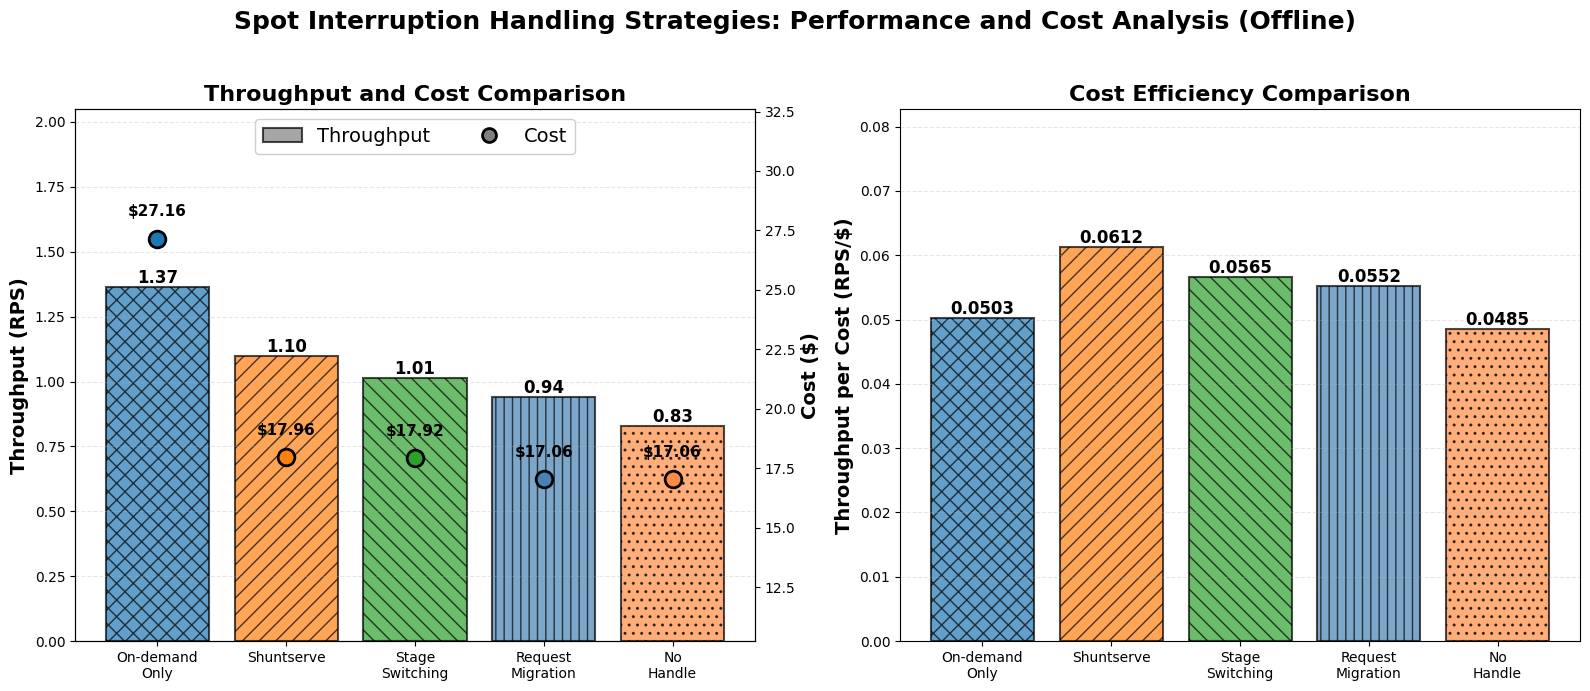

In [72]:
# Plot the analysis
throughputs_list = [ondemand_throughput, shuntserve_throughput, stage_switching_throughput, request_migration_throughput, no_handle_throughput]
costs_list = [ondemand_only_price, shuntserve_total_price, stage_switching_total_price, request_migration_price, no_handle_price]
throughput_per_costs_list = [ondemand_only_throughput_per_cost, shuntserve_throughput_per_cost, stage_switching_throughput_per_cost, request_migration_throughput_per_cost, no_handle_throughput_per_cost]

plot_throughput_cost_analysis(
    throughputs=throughputs_list,
    costs=costs_list,
    approaches=['On-demand\nOnly', 'Shuntserve', 'Stage\nSwitching', 'Request\nMigration', 'No\nHandle'],
    throughput_per_costs=throughput_per_costs_list,
    title_suffix='Offline',
    font_size_title=18,
    font_size_subtitle=16,
    font_size_label=14,
    font_size_value=12,
    font_size_legend=14
)